In [30]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable


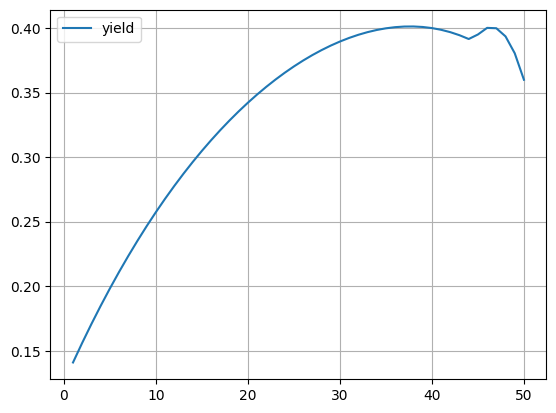

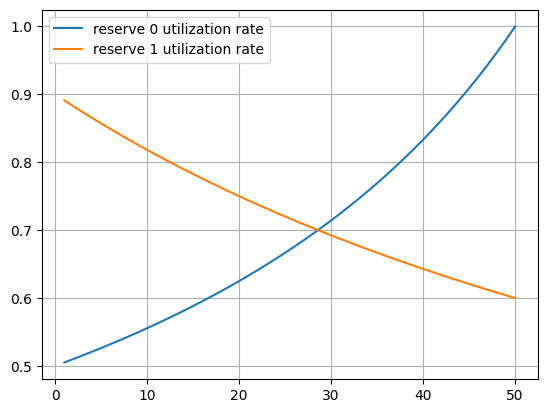

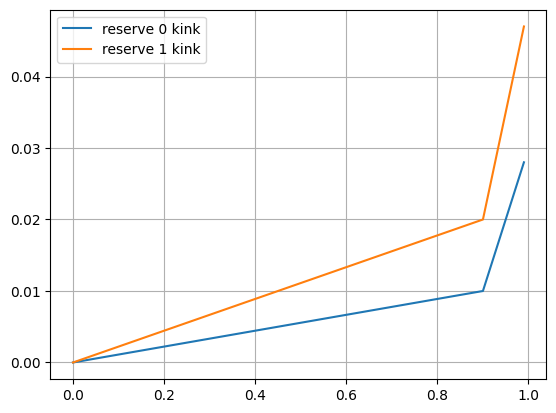

optimal dx = 37.6244
optimal x0 = 12.3756, x1 = 37.6244


In [1]:
import math

from matplotlib import pyplot as plt
from scipy.optimize import brentq


def calc_interest_rates(r0, r1, r2, u_opt, available_liq, debt, fee):
    assert 0 <= fee <= 1

    total = available_liq + debt
    u = 0 if total == 0 else debt / total

    borrow_rate = r0
    if u <= u_opt:
        borrow_rate += r1 * u / u_opt
    else:
        borrow_rate += r1 + r2 * (u - u_opt) / (1 - u_opt)

    liq_rate = borrow_rate * u * (1 - fee)

    return (borrow_rate, liq_rate, u)


def kink(r0, r1, r2, u_opt, u):
    assert 0 <= u_opt <= 1
    assert 0 <= u <= 1

    b = r0
    if u <= u_opt:
        b += r1 * u / u_opt
    else:
        b += r1 + r2 * (u - u_opt) / (1 - u_opt)
    return b


class Reserve:
    def __init__(self, **kwargs):
        self.liq_index = 1
        self.borrow_index = 1
        self.liq_rate = 0
        self.borrow_rate = 0
        self.fee = kwargs.get("fee", 0)
        self.last_update_time = kwargs["time"]
        self.underlying_supplied = 0
        self.underlying_borrowed = 0
        # Interest rates
        self.r0 = kwargs["r0"]
        self.r1 = kwargs["r1"]
        self.r2 = kwargs["r2"]
        # Optimal utilization rate
        self.u_opt = kwargs["u_opt"]
        # Utilization rate
        self.u = 0

    def update(self, **kwargs):
        t = kwargs["time"]
        if t == self.last_update_time:
            return

        dt = t - self.last_update_time
        self.liq_index *= 1 + self.liq_rate * dt
        self.borrow_index *= (1 + self.borrow_rate) ** dt
        self.last_update_time = t

    def update_interest_rates(self):
        a_supply = self.underlying_supplied * self.liq_index
        debt = self.underlying_borrowed * self.borrow_index

        s = self.underlying_supplied
        b = self.underlying_borrowed
        d = b * self.borrow_index
        available_liq = s - b

        (borrow_rate, liq_rate, u) = calc_interest_rates(
            self.r0, self.r1, self.r2, self.u_opt, available_liq, debt, self.fee
        )

        self.liq_rate = liq_rate
        self.borrow_rate = borrow_rate
        self.u = u


# Protocol fee
FEE = 0.1

# Supplied to reserve 0
S0 = 100
# Borrowed from reserve 0
B0 = 50
# Amount user can withdraw from reserve 0
X0 = 50
assert X0 <= (S0 - B0)

# Supplied to reserve 1
S1 = 100
# Borrowed from reserve 1
B1 = 90
# Amount user can withdraw from reserve 1
X1 = 0
assert X1 <= (S1 - B1)


r0 = Reserve(fee=FEE, time=0, r0=0, r1=0.01, r2=0.02, u_opt=0.9)
r0.underlying_supplied = S0
r0.underlying_borrowed = B0

r1 = Reserve(fee=FEE, time=0, r0=0, r1=0.02, r2=0.03, u_opt=0.9)
r1.underlying_supplied = S1
r1.underlying_borrowed = B1

# dx
xs = []
# total yield
ys = []
# Reserve 0 utilization rate
u0 = []
# Reserve 1 utilization rate
u1 = []


r0.update(time=100)
r1.update(time=100)
r0.update_interest_rates()
r1.update_interest_rates()


# Plot total yields as liquidity is moved from reserve 0 to 1
for dx in range(1, X0 + 1):
    x0 = X0 - dx
    x1 = X1 + dx

    r0.underlying_supplied = S0 - dx
    r1.underlying_supplied = S1 + dx

    r0.update_interest_rates()
    r1.update_interest_rates()

    y0 = r0.liq_rate
    y1 = r1.liq_rate

    # Total yield of the user
    # For dx small, y0  and y1 does not change much
    # so replace y0 and y1 with constants c0 and c1
    # y ~ c0 * (X0 - dx) + c1 * (X1 - dx)
    #   = c0 * X0 + c1 * X1 + (c1 - c0) * dx (max when c1 > c0 and dx = X0)
    y = y0 * x0 + y1 * x1

    ys.append(y)
    xs.append(dx)
    u0.append(r0.u)
    u1.append(r1.u)


plt.figure()
plt.plot(xs, ys, label="yield")
plt.grid(True)
plt.legend()
plt.show()


plt.figure()
plt.plot(xs, u0, label="reserve 0 utilization rate")
plt.plot(xs, u1, label="reserve 1 utilization rate")
plt.grid(True)
plt.legend()
plt.show()

# Interest rates
us = []
# Reserve 0 borrow rate
b0s = []
# Reserve 1 borrow rate
b1s = []

for i in range(0, 100):
    u = i / 100
    b0 = kink(r0.r0, r0.r1, r0.r2, r0.u_opt, u)
    b1 = kink(r1.r0, r1.r1, r1.r2, r1.u_opt, u)
    b0s.append(b0)
    b1s.append(b1)
    us.append(u)


plt.figure()
plt.plot(us, b0s, label="reserve 0 kink")
plt.plot(us, b1s, label="reserve 1 kink")
plt.grid(True)
plt.legend()
plt.show()


# Numerical approximation to optimal dx
def fy(dx):
    r0.underlying_supplied = S0 - dx
    r1.underlying_supplied = S1 + dx
    r0.update_interest_rates()
    r1.update_interest_rates()
    x0 = X0 - dx
    x1 = X1 + dx
    return r0.liq_rate * x0 + r1.liq_rate * x1


def dy(dx, eps=0.5):
    return fy(dx + eps) - fy(dx - eps)


dx_opt = brentq(dy, 1, X0 - 1)
print(f"optimal dx = {dx_opt:.4f}")
print(f"optimal x0 = {X0 - dx_opt:.4f}, x1 = {X1 + dx_opt:.4f}")